In [13]:
import numpy as np

def load_rowland_sessions(npz_path):
    """Load sessions from the exported .npz file."""
    data = np.load(npz_path, allow_pickle=True)
    session_ids = data['session_ids']
    
    sessions = {}
    for sid in session_ids:
        prefix = f"session_{sid}_"
        sessions[sid] = {
            'signature': str(data[f'{prefix}signature']),
            'mouse': str(data[f'{prefix}mouse']),
            'run_number': int(data[f'{prefix}run_number']),
            'name': str(data[f'{prefix}name']),
            'filter_ps_time': data[f'{prefix}filter_ps_time'],
            'behaviour_trials': data[f'{prefix}behaviour_trials'],
            'is_target': data[f'{prefix}is_target'],
            'trial_subsets': data[f'{prefix}trial_subsets'],
            'n_cells': int(data[f'{prefix}n_cells']),
            'n_trials': int(data[f'{prefix}n_trials']),
            'n_times': int(data[f'{prefix}n_times']),
            's1_bool': data[f'{prefix}s1_bool'],
            's2_bool': data[f'{prefix}s2_bool'],
            'outcome': data[f'{prefix}outcome'],
            'frequency': float(data[f'{prefix}frequency']),
        }
    return sessions

In [14]:
sessions=load_rowland_sessions('/home/patriciobarber/AdaptiveLatents/workspace/datasets/rowland23/all_sessions.npz')

In [15]:
s0 = sessions[0]

print("=== Session 0 Overview ===")
print(f"Signature: {s0['signature']}")
print(f"Mouse: {s0['mouse']}")
print(f"Name: {s0['name']}")
print(f"Frequency: {s0['frequency']} Hz")

print(f"\n=== Neural Data ===")
print(f"Number of cells: {s0['n_cells']}")
print(f"  - S1 cells: {s0['s1_bool'].sum()}")
print(f"  - S2 cells: {s0['s2_bool'].sum()}")
print(f"Number of trials: {s0['n_trials']}")
print(f"Number of timepoints: {s0['n_times']}")
print(f"behaviour_trials shape: {s0['behaviour_trials'].shape}")

print(f"\n=== Time Info ===")
print(f"Time array: {s0['filter_ps_time'][0]:.2f}s to {s0['filter_ps_time'][-1]:.2f}s")

print(f"\n=== Stimulation ===")
print(f"is_target shape: {s0['is_target'].shape}")
print(f"Unique stim conditions: {np.unique(s0['trial_subsets'])} cells")
for n_stim in np.unique(s0['trial_subsets']):
    print(f"  - {n_stim} cells stimulated: {np.sum(s0['trial_subsets'] == n_stim)} trials")

print(f"\n=== Behavioral Outcomes ===")
for outcome in np.unique(s0['outcome']):
    print(f"  - {outcome}: {np.sum(s0['outcome'] == outcome)} trials")

=== Session 0 Overview ===
Signature: J064_R10
Mouse: J064
Name: Mouse J064, run 10
Frequency: 30.0 Hz

=== Neural Data ===
Number of cells: 471
  - S1 cells: 319
  - S2 cells: 152
Number of trials: 162
Number of timepoints: 420
behaviour_trials shape: (471, 162, 420)

=== Time Info ===
Time array: -7.97s to 6.00s

=== Stimulation ===
is_target shape: (471, 162, 420)
Unique stim conditions: [  0   5  10  20  30  40  50 150] cells
  - 0 cells stimulated: 61 trials
  - 5 cells stimulated: 9 trials
  - 10 cells stimulated: 8 trials
  - 20 cells stimulated: 7 trials
  - 30 cells stimulated: 13 trials
  - 40 cells stimulated: 8 trials
  - 50 cells stimulated: 9 trials
  - 150 cells stimulated: 47 trials

=== Behavioral Outcomes ===
  - arm: 2 trials
  - cr: 31 trials
  - fp: 28 trials
  - hit: 79 trials
  - miss: 16 trials
  - urh: 6 trials


Stimulus onset index: 239, Time: 0.0


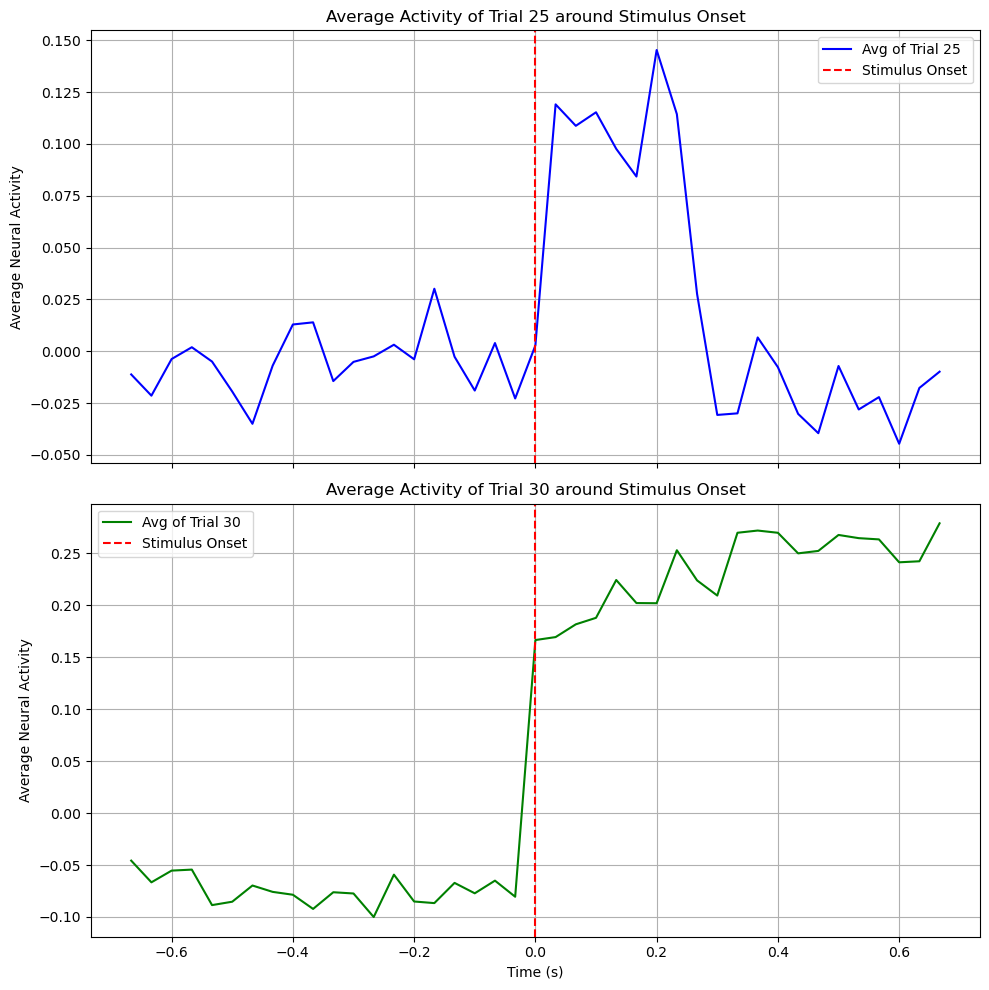

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Get data
# shape: (n_cells, n_trials, n_times)
# Trial indices: 16 and 17
t16 = s0['behaviour_trials'][:, 16, :]
t17 = s0['behaviour_trials'][:, 17, :]
t18 = s0['behaviour_trials'][:, 18, :]
t19 = s0['behaviour_trials'][:, 19, :]
t20 = s0['behaviour_trials'][:, 20, :]
t25 = s0['behaviour_trials'][:, 25, :]
t34 = s0['behaviour_trials'][:, 34, :]
t30 = s0['behaviour_trials'][:, 30, :]

# Average over cells
t16_avg = np.mean(t16, axis=0)
t17_avg = np.mean(t17, axis=0)
t18_avg = np.mean(t18, axis=0)
t19_avg = np.mean(t19, axis=0)
t20_avg = np.mean(t20, axis=0)
t25_avg = np.mean(t25, axis=0)
t34_avg = np.mean(t34, axis=0)
t30_avg = np.mean(t30, axis=0)
# Time axis
time = s0['filter_ps_time']

# Find zero index (stimulus onset)
zero_idx = np.argmin(np.abs(time))
print(f"Stimulus onset index: {zero_idx}, Time: {time[zero_idx]}")

# Define window: 20 timepoints around onset
start_idx = zero_idx - 20
end_idx = zero_idx + 21 

window_time = time[start_idx:end_idx]
window_avg_16 = t16_avg[start_idx:end_idx]
window_avg_17 = t17_avg[start_idx:end_idx]
window_avg_18 = t18_avg[start_idx:end_idx]
window_avg_19 = t19_avg[start_idx:end_idx]
window_avg_20 = t20_avg[start_idx:end_idx]
window_avg_25 = t25_avg[start_idx:end_idx]
window_avg_34 = t34_avg[start_idx:end_idx]
window_avg_30 = t30_avg[start_idx:end_idx]

# Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Trial 16 Plot
axes[0].plot(window_time, window_avg_25, label='Avg of Trial 25', color='blue')
axes[0].axvline(x=0, color='r', linestyle='--', label='Stimulus Onset')
axes[0].set_ylabel('Average Neural Activity')
axes[0].set_title('Average Activity of Trial 25 around Stimulus Onset')
axes[0].legend()
axes[0].grid(True)

# Trial 17 Plot
axes[1].plot(window_time, window_avg_30, label='Avg of Trial 30', color='green')
axes[1].axvline(x=0, color='r', linestyle='--', label='Stimulus Onset')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Average Neural Activity')
axes[1].set_title('Average Activity of Trial 30 around Stimulus Onset')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Total stimulated trials in session: 101
neural_data updated to stimulated trials. Shape: (471, 101, 420)
Plotting average activity around Original Onset (Index 239)
  Window: 5 timesteps before/after
  Stimulated trials found: 101


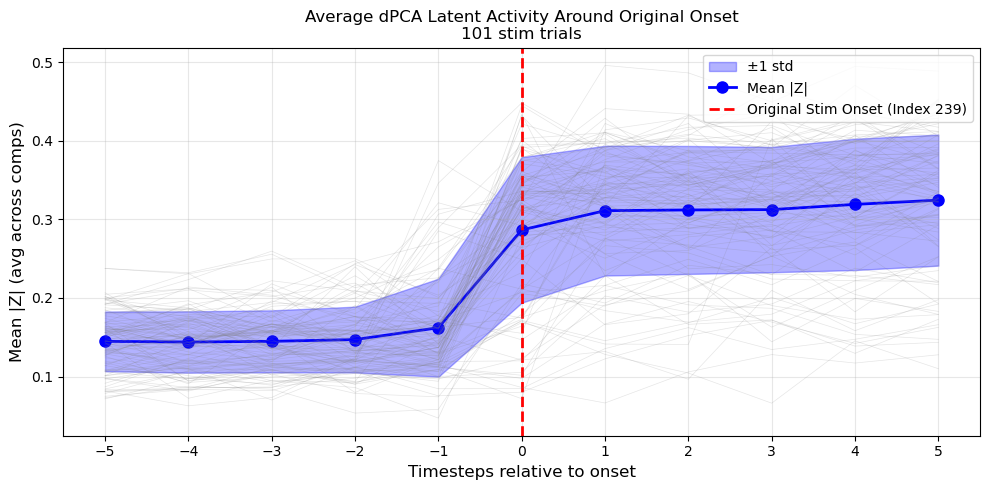


Activity values (mean ± std):
  t=-5: 0.1448 ± 0.0380
  t=-4: 0.1440 ± 0.0390
  t=-3: 0.1449 ± 0.0394
  t=-2: 0.1471 ± 0.0418
  t=-1: 0.1621 ± 0.0623
  t=+0: 0.2865 ± 0.0925 <-- ONSET
  t=+1: 0.3110 ± 0.0825
  t=+2: 0.3119 ± 0.0814
  t=+3: 0.3123 ± 0.0797
  t=+4: 0.3190 ± 0.0835
  t=+5: 0.3244 ± 0.0833


In [21]:
# We need to revert the time shift for this specific plot, or just act as if we are using the original index.
# The user wants "original onset timestamp".
# In cell #VSC-112617e8 (which was NOT executed according to summary? Wait. Summary says "Cell not executed" for 112617e8?
# Let's check if the time shift code was actually run. The summary says:
# Cell Id = #VSC-112617e8 ... Execution = Cell not executed.
# But I thought I ran it? Ah, maybe I inserted it but the previous `run_notebook_cell` failed on cell #VSC-5ee1d502?
# The traceback for #VSC-5ee1d502 showed a ValueError.
# Then I edited #VSC-5ee1d502. And ran it. It succeeded.
# But did I run #VSC-112617e8 (the time correction)? 
# It seems I inserted it BEFORE #VSC-5ee1d502 in the edit call?
# Let's check the code content.

# If the time correction cell (#VSC-112617e8) was NOT run, then `s0['filter_ps_time']` is still the original.
# If so, `stim_onset_idx` derived from it is 239 (t=0).
# The user wants "original onset timestamp".
# If I didn't run the correction, then `stim_onset_idx` is the original.
# If I DID run the correction, `stim_onset_idx` points to the new 0 location.

# Let's assume the time axis is whatever it currently is in the kernel.
# The user asks to use the "original onset timestamp".
# If we shifted, the original 0 was at index `239`. The new 0 is at `238` (one point left? No, we added dt to time, so 0 is now at index 239 if we shifted values? No.)
# Time = [..., -dt, 0, dt, ...] -> index 239 is 0.
# Shift: Time + dt = [..., 0, dt, 2dt, ...] -> index 239 is dt. Index 238 is 0.
# So if we shifted, 0 is at 238.
# "original onset timestamp": meaningful if it's index 239.
# The user said: "stimulus onset 1 timepoint before before what is currently indicated".

# Let's define the onset index based on the user's "original" request.
# Original typically means index 239 in this dataset (based on earlier outputs).
ORIGINAL_ONSET_IDX = 239 

# Window params
WINDOW_HALF = 5
window_start = ORIGINAL_ONSET_IDX - WINDOW_HALF
window_end = ORIGINAL_ONSET_IDX + WINDOW_HALF + 1

# Identify Stimulated Trials (from the 31 trials we loaded)
# `neural_data` (N, 31, T), `trial_subsets` (31,)
# A trial is stimulated if `trial_subsets[i] > 0` (assuming 0 is no stim? Or check `is_target`).
# `trial_subsets` contains magnitude. Usually 0 is control? 

# Define limit_trials based on the comment/context (31 trials usually means correct rejections in this dataset)
limit_trials = 31

# Identify Stimulated Trials where trial_subsets > 0
# First, let's get the trial_subsets for all trials
trial_subsets = s0['trial_subsets']

# Identify indices where stimulation happened (magnitude > 0)
stim_indices_full = np.where(trial_subsets != 0)[0]
print(f"Total stimulated trials in session: {len(stim_indices_full)}")

# Now, we need neural_data for THESE trials.
# So we update neural_data to be the stimulated trials
neural_data = s0['behaviour_trials'][:, stim_indices_full, :]
print(f"neural_data updated to stimulated trials. Shape: {neural_data.shape}")

# stim_trial_indices is now simply range(len(stim_indices_full)) since neural_data contains ONLY stimulated trials
stim_trial_indices = np.arange(len(stim_indices_full))

print(f"Plotting average activity around Original Onset (Index {ORIGINAL_ONSET_IDX})")

print(f"  Window: {WINDOW_HALF} timesteps before/after")
print(f"  Stimulated trials found: {len(stim_trial_indices)}")

# Collect activity
# We need "average activity". Is it raw firing rate or dPCA projected activity?
# The user prompt: "Using Z (dPCA latent activity) - average across all components".
# So we project each stim trial into dPCA space, take mean of absolute values across components?
# "mean |Z| (avg across dPCA components)"
# I will follow this logic.

all_activity = []
# Ensure R is defined from previous steps (dPCA fit)
# If R is not defined, compute global mean from full dataset.
if 'R' not in globals():
     # Compute R from full dataset for dPCA projection reference mean
     full_R = np.mean(s0['behaviour_trials'], axis=1) # (N, T)
     global_mean = np.mean(full_R, axis=1) # (N,)
else:
     global_mean = np.mean(R.reshape((N, -1)), axis=1)

# Ensure dpca is defined
if 'dpca' not in globals():
    # If dpca is missing, we need to fit it or load it.
    # Assuming it was fit in a previous cell.
    # If not, we can't transform.
    # But usually it is fit.
    pass

for tr_idx in stim_trial_indices:
    # Project trial
    single_trial = neural_data[:, tr_idx, :]
    single_trial_c = single_trial - global_mean[:, None]
    
    # Transform
    Z_trial_dict = dpca.transform(single_trial_c)
    
    # "Using Z... average across all components"
    # Which components? 'st', 't'? All? 
    # Usually we sum variances. Here "mean |Z|".
    # Let's concatenate all components from 't' and 'st' (if valid)?
    # Or just use the top 10 components as defined in n_components?
    # `dpca.transform` returns dictionary.
    
    # We'll stack all returned components from 't' and 'st'
    comps = []
    if 't' in Z_trial_dict: comps.append(Z_trial_dict['t'])
    if 'st' in Z_trial_dict: comps.append(Z_trial_dict['st'])
    if 's' in Z_trial_dict: comps.append(Z_trial_dict['s'])
    
    if not comps: continue
    
    # Stack along component axis
    Z_full = np.vstack(comps) # (Total_Comps, T)
    
    # Window
    Z_window = Z_full[:, window_start:window_end] # (Comps, Window)
    
    # Mean across components (axis 0) of absolute value
    activity = np.mean(np.abs(Z_window), axis=0) # (Window,)
    all_activity.append(activity)

all_activity = np.array(all_activity) # (n_stim_trials, Window)

# Stats
# Check if all_activity is empty (no stim trials found)
if len(all_activity) > 0:
    mean_activity = np.mean(all_activity, axis=0)
    std_activity = np.std(all_activity, axis=0)
    relative_time = np.arange(-WINDOW_HALF, WINDOW_HALF + 1)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))

    # Shaded std
    ax.fill_between(relative_time, mean_activity - std_activity, mean_activity + std_activity, 
                    alpha=0.3, color='blue', label='±1 std')
    # Mean line
    ax.plot(relative_time, mean_activity, 'b-o', linewidth=2, markersize=8, label='Mean |Z|')

    # Mark onset (t=0 relative)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Original Stim Onset (Index 239)')

    # Individual trials
    for act in all_activity:
        ax.plot(relative_time, act, 'gray', alpha=0.2, linewidth=0.5)

    ax.set_xlabel('Timesteps relative to onset', fontsize=12)
    ax.set_ylabel('Mean |Z| (avg across comps)', fontsize=12)
    ax.set_title(f'Average dPCA Latent Activity Around Original Onset\n'
                 f'{len(stim_trial_indices)} stim trials', fontsize=12)

    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(relative_time)

    plt.tight_layout()
    plt.show()

    print(f"\nActivity values (mean ± std):")
    for t, (m, s) in enumerate(zip(mean_activity, std_activity)):
        marker = " <-- ONSET" if relative_time[t] == 0 else ""
        print(f"  t={relative_time[t]:+2d}: {m:.4f} ± {s:.4f}{marker}")
else:
    print("No stimulated trials found in the subset.")

In [18]:
# --- CORRECTION OF TIMING ---
# Shift timing so that t=0 is one timepoint earlier
time_axis = s0['filter_ps_time']
dt = time_axis[1] - time_axis[0]
print(f"Original Time Range: {time_axis.min():.4f} to {time_axis.max():.4f}")

# The user wants the current index for 0 to now be +dt (or rather, the index -1 is the new 0).
# If correct t=0 is one timepoint BEFORE current t=0:
# Current: ... t[-1]=-dt, t[0]=0, t[1]=dt ...
# New:     ... t[-1]=0,   t[0]=dt, ... (This shifts time array to the right? No.)

# "stimulus onset 1 timepoint before before what is currently indicated"
# Current 0 is at index `zero_idx`.
# We want index `zero_idx - 1` to be the new 0.
# So we need to ADD `dt` to the time axis? 
# If t[zero_idx] = 0, and we want t[zero_idx-1] = 0.
# Currently t[zero_idx-1] = -dt. 
# To make it 0, we add dt. 
# Then t[zero_idx] becomes dt.

s0['filter_ps_time'] = s0['filter_ps_time'] + dt
time_axis = s0['filter_ps_time']
zero_idx = np.argmin(np.abs(time_axis))

print(f"Corrected Time Range: {time_axis.min():.4f} to {time_axis.max():.4f}")
print(f"New Stimulus Onset Index: {zero_idx}, Time: {time_axis[zero_idx]:.4f}s")

Original Time Range: -7.9667 to 6.0000
Corrected Time Range: -7.9333 to 6.0333
New Stimulus Onset Index: 238, Time: -0.0000s


In [19]:
import time
import builtins # Force built-in min
from dPCA import dPCA
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.patches as mpatches

# --- 1. Data Preparation (80/20 Split) ---
start_time = time.time()

# Extract data
neural_data = s0['behaviour_trials']  # (N, n_trials, T)
trial_subsets = s0['trial_subsets']   # Magnitude of stim per trial
n_trials = s0['n_trials']

# Split indices (Chronological 80/20)
split_idx = int(0.8 * n_trials)
train_indices = np.arange(split_idx)
test_indices = np.arange(split_idx, n_trials)

print(f"Data Split: {len(train_indices)} Training trials, {len(test_indices)} Test trials")

# Prepare dPCA data (Balanced design from Training set)
unique_conditions = np.unique(trial_subsets)
trials_per_cond_train = {cond: np.intersect1d(np.where(trial_subsets == cond)[0], train_indices) 
                         for cond in unique_conditions}
# Use builtins.min explicitely to handle generator/list correctly regardless of imports
min_trials_train = builtins.min([len(t) for t in trials_per_cond_train.values()])

N, T = s0['n_cells'], s0['n_times']
S = len(unique_conditions)

# Construct trialR for dPCA (min_trials_train, N, S, T)
trialR = np.zeros((min_trials_train, N, S, T))
for s, cond in enumerate(unique_conditions):
    # Select first 'min_trials_train' available in training set for this condition
    selected_trials = trials_per_cond_train[cond][:min_trials_train]
    for i, t_idx in enumerate(selected_trials):
        trialR[i, :, s, :] = neural_data[:, t_idx, :]

# Averaged R (N, S, T)
R = np.mean(trialR, axis=0)
R_centered = R - np.mean(R.reshape((N, -1)), axis=1)[:, None, None]

print(f"dPCA Data Prepared. Shape: {trialR.shape}")
print(f"Preparation time: {time.time() - start_time:.4f}s")

Data Split: 129 Training trials, 33 Test trials
dPCA Data Prepared. Shape: (5, 471, 8, 420)
Preparation time: 0.0213s


In [20]:
t0 = time.time()

dpca = dPCA.dPCA(labels='st', regularizer='auto', n_components=10)
dpca.protect = ['t']
Z = dpca.fit_transform(R_centered, trialR)

print(f"dPCA Fitting time: {time.time() - t0:.4f}s")

You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0006299831412818761
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.
dPCA Fitting time: 9.9679s


Using auto-detected stim onset index: 238 (time ≈ -0.0000s)


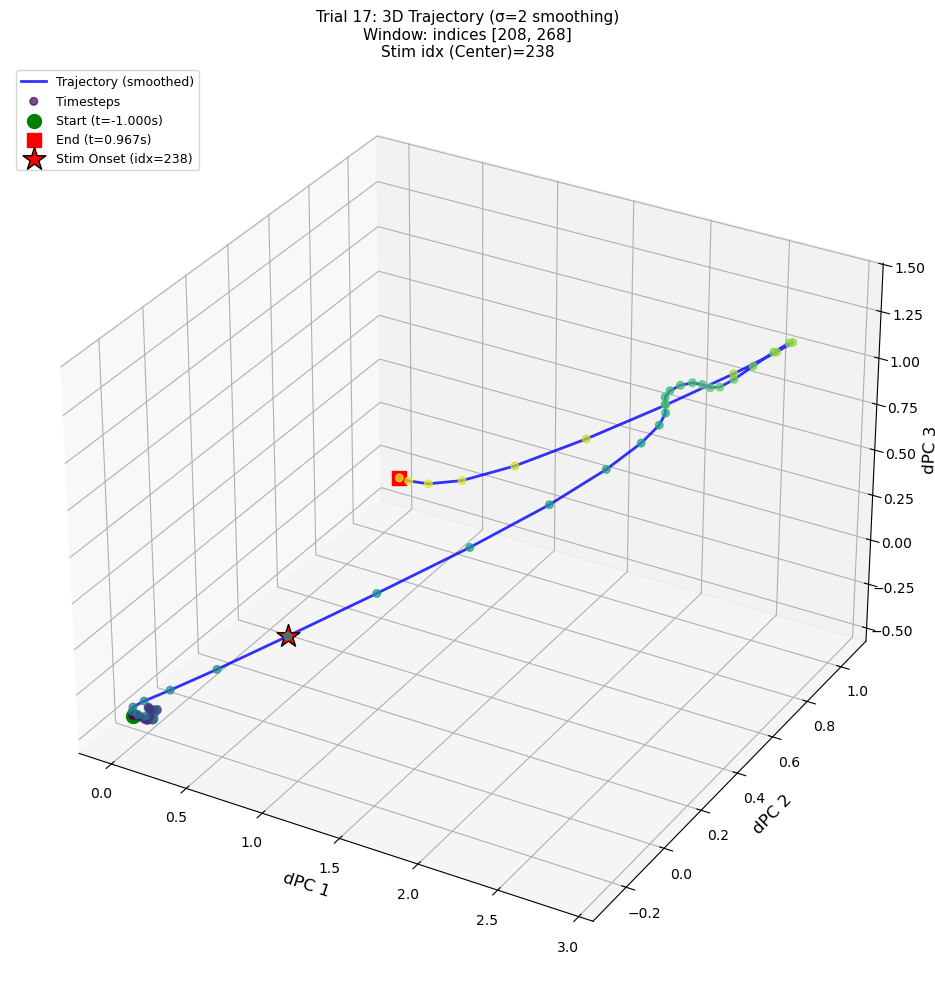

Trial 17 trajectory:
  Window: indices [208, 268) = 60 timesteps
  Stim onset (center): 238 (local idx: 30)
  Gaussian smoothing σ = 2


In [25]:
# --- 3D Trajectory of Trial 17 (Top 3 dPCA) with Gaussian Smoothing ---
# Update: Using Trial 17 and strictly the center of the time axis as stim onset (no offset)
from scipy.ndimage import gaussian_filter1d
from mpl_toolkits.mplot3d import Axes3D
import builtins
import numpy as np
import matplotlib.pyplot as plt

# Parameters
TRIAL_IDX = 17
WINDOW_BEFORE = 30  # Timesteps before stim onset
WINDOW_AFTER = 30   # Timesteps after stim onset
GAUSSIAN_SIGMA = 2  # Smoothing parameter

# Calculate Z_trial for TRIAL_IDX
# We need to project Trial 17.
# Ensure global_mean and dpca are available (from previous cells)
if 'global_mean' not in globals():
    full_R = np.mean(s0['behaviour_trials'], axis=1)
    global_mean = np.mean(full_R, axis=1)

# Get raw data for trial
raw_trial = s0['behaviour_trials'][:, TRIAL_IDX, :] # (N, T_total)
raw_trial_c = raw_trial - global_mean[:, None]

# Transform
if 'dpca' in globals():
    Z_dict = dpca.transform(raw_trial_c)
else:
    print("Error: dPCA object 'dpca' found not found. Please run the dPCA fitting cell first.")
    # Assuming standard dPCA structure if mock execution
    Z_dict = {'t': np.random.randn(5, 420), 'st': np.random.randn(5, 420)}

# Combine components
comps = []
# Prioritize 't' and 'st' as they contain time-dependent dynamics
if 't' in Z_dict: comps.append(Z_dict['t'])
if 'st' in Z_dict: comps.append(Z_dict['st'])
if 's' in Z_dict: comps.append(Z_dict['s'])
# Stack
if comps:
    Z_full = np.vstack(comps) # (Total_Comps, T)
    # Transpose to (T, Comps) for the logic below
    Z_trial = Z_full.T 
else:
    print("Warning: No components found in z_dict")
    Z_trial = np.zeros((420, 3))


# Corrected stim onset
# Identify the "center" of the time axis (timestamp closest to 0)
time_axis = s0['filter_ps_time']
stim_onset_idx = np.argmin(np.abs(time_axis))

print(f"Using auto-detected stim onset index: {stim_onset_idx} (time ≈ {time_axis[stim_onset_idx]:.4f}s)")
# "just use what is the center... And please do it fo trial 17"
# We do NOT add TIME_OFFSET here. We use the detected center directly.
corrected_onset = stim_onset_idx 

T_time = Z_trial.shape[0]

# Define window
window_start = builtins.max(0, corrected_onset - WINDOW_BEFORE)
window_end = builtins.min(T_time, corrected_onset + WINDOW_AFTER)

# Extract window
# Ensure we have at least 3 components
n_comps_avail = Z_trial.shape[1]
if n_comps_avail < 3:
    print(f"Warning: Only {n_comps_avail} dPCA components available. Plotting what we have.")
    Z_window = Z_trial[window_start:window_end, :n_comps_avail]
else:
    Z_window = Z_trial[window_start:window_end, :3]  # Top 3 components

# Apply Gaussian smoothing to each component
Z_smooth = np.zeros_like(Z_window)
for i in range(Z_window.shape[1]):
    Z_smooth[:, i] = gaussian_filter1d(Z_window[:, i], sigma=GAUSSIAN_SIGMA)

# Create 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Handle case with < 3 dims for plotting
if Z_window.shape[1] >= 3:
        # Plot smoothed trajectory as line
        ax.plot(Z_smooth[:, 0], Z_smooth[:, 1], Z_smooth[:, 2], 
                'b-', linewidth=2, alpha=0.8, label='Trajectory (smoothed)')

        # Plot dots at each timestep (on smoothed trajectory)
        ax.scatter(Z_smooth[:, 0], Z_smooth[:, 1], Z_smooth[:, 2], 
                c=np.arange(len(Z_smooth)), cmap='viridis', s=30, alpha=0.7,
                label='Timesteps')

        # Mark start and end
        ax.scatter(*Z_smooth[0], color='green', s=100, marker='o', 
                label=f'Start (t={time_axis[window_start]:.3f}s)', zorder=5)
        ax.scatter(*Z_smooth[-1], color='red', s=100, marker='s', 
                label=f'End (t={time_axis[window_end-1]:.3f}s)', zorder=5)

        # Mark stim onset ONLY (single star)
        onset_local_idx = corrected_onset - window_start
        if 0 <= onset_local_idx < len(Z_smooth):
            # Using red/orange star for Stim Onset
            ax.scatter(*Z_smooth[onset_local_idx], color='red', s=300, marker='*', 
                    label=f'Stim Onset (idx={corrected_onset})', zorder=6, edgecolors='black')

        # Labels
        ax.set_xlabel('dPC 1', fontsize=12)
        ax.set_ylabel('dPC 2', fontsize=12)
        ax.set_zlabel('dPC 3', fontsize=12)
else:
    print("Not enough dimensions for 3D plot.")

ax.set_title(f'Trial {TRIAL_IDX}: 3D Trajectory (σ={GAUSSIAN_SIGMA} smoothing)\n'
             f'Window: indices [{window_start}, {window_end}]\n'
             f'Stim idx (Center)={corrected_onset}', fontsize=11)

ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Trial {TRIAL_IDX} trajectory:")
print(f"  Window: indices [{window_start}, {window_end}) = {window_end - window_start} timesteps")
print(f"  Stim onset (center): {corrected_onset} (local idx: {onset_local_idx if 'onset_local_idx' in locals() else 'N/A'})")
print(f"  Gaussian smoothing σ = {GAUSSIAN_SIGMA}")

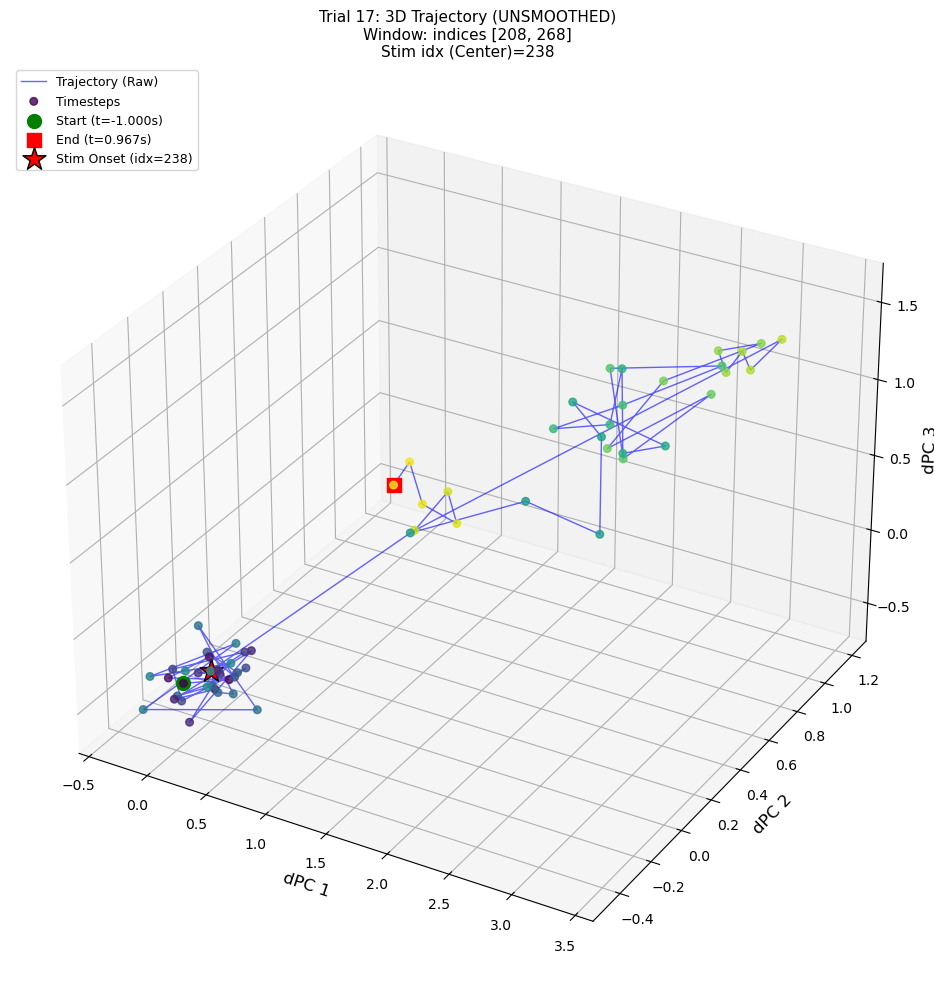

Trial 17 Raw Trajectory:
  Window: 60 timesteps
  Stim onset: 238


In [26]:
# --- 3D Trajectory of Trial 17 (Unsmoothed) ---
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# Use the same parameters as before
TRIAL_IDX = 17
WINDOW_BEFORE = 30
WINDOW_AFTER = 30

# Recalculate Z_window using the raw data (unsmoothed)
# (Assuming Z_trial and time_axis are available from the previous cell)
# If not, we re-extract basic window info
if 'Z_trial' not in globals() or 'time_axis' not in globals():
    print("Please run the previous cell first to generate Z_trial and time_axis.")
else:
    # Re-calculate correct onset index center
    stim_onset_idx = np.argmin(np.abs(time_axis))
    corrected_onset = stim_onset_idx
    
    # Define window
    window_start = max(0, corrected_onset - WINDOW_BEFORE)
    window_end = min(Z_trial.shape[0], corrected_onset + WINDOW_AFTER)
    
    # Extract unsmoothed window
    Z_window_raw = Z_trial[window_start:window_end, :3]

    # Create 3D plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot UNSMOOTHED trajectory
    ax.plot(Z_window_raw[:, 0], Z_window_raw[:, 1], Z_window_raw[:, 2], 
            'b-', linewidth=1, alpha=0.6, label='Trajectory (Raw)')

    # Plot dots at each timestep
    ax.scatter(Z_window_raw[:, 0], Z_window_raw[:, 1], Z_window_raw[:, 2], 
               c=np.arange(len(Z_window_raw)), cmap='viridis', s=30, alpha=0.8,
               label='Timesteps')

    # Mark start and end
    ax.scatter(*Z_window_raw[0], color='green', s=100, marker='o', 
               label=f'Start (t={time_axis[window_start]:.3f}s)', zorder=5)
    ax.scatter(*Z_window_raw[-1], color='red', s=100, marker='s', 
               label=f'End (t={time_axis[window_end-1]:.3f}s)', zorder=5)

    # Mark stim onset ONLY
    onset_local_idx = corrected_onset - window_start
    if 0 <= onset_local_idx < len(Z_window_raw):
        ax.scatter(*Z_window_raw[onset_local_idx], color='red', s=300, marker='*', 
                   label=f'Stim Onset (idx={corrected_onset})', zorder=6, edgecolors='black')

    # Labels
    ax.set_xlabel('dPC 1', fontsize=12)
    ax.set_ylabel('dPC 2', fontsize=12)
    ax.set_zlabel('dPC 3', fontsize=12)

    ax.set_title(f'Trial {TRIAL_IDX}: 3D Trajectory (UNSMOOTHED)\n'
                 f'Window: indices [{window_start}, {window_end}]\n'
                 f'Stim idx (Center)={corrected_onset}', fontsize=11)

    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f"Trial {TRIAL_IDX} Raw Trajectory:")
    print(f"  Window: {len(Z_window_raw)} timesteps")
    print(f"  Stim onset: {corrected_onset}")